In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import openpyxl
import seaborn as snb

Reading the file

In [56]:
df= pd.read_csv('Extended_Employee_Performance_and_Productivity_Data.csv')

Data exploration

In [57]:
# Check the shape of the DataFrame
df.shape

(100000, 20)

In [58]:
# Check the data types of the columns
df.dtypes

Employee_ID                      int64
Department                         str
Gender                             str
Age                              int64
Job_Title                          str
Hire_Date                          str
Years_At_Company                 int64
Education_Level                    str
Performance_Score                int64
Monthly_Salary                 float64
Work_Hours_Per_Week              int64
Projects_Handled                 int64
Overtime_Hours                   int64
Sick_Days                        int64
Remote_Work_Frequency            int64
Team_Size                        int64
Training_Hours                   int64
Promotions                       int64
Employee_Satisfaction_Score    float64
Resigned                          bool
dtype: object

In [59]:
#change Hire_data from string to date
df['Hire_Date']=pd.to_datetime(df['Hire_Date'])

In [60]:
#check data types
df['Hire_Date'].dtype

dtype('<M8[us]')

In [61]:
#check for missing values
df.isnull().sum()

Employee_ID                    0
Department                     0
Gender                         0
Age                            0
Job_Title                      0
Hire_Date                      0
Years_At_Company               0
Education_Level                0
Performance_Score              0
Monthly_Salary                 0
Work_Hours_Per_Week            0
Projects_Handled               0
Overtime_Hours                 0
Sick_Days                      0
Remote_Work_Frequency          0
Team_Size                      0
Training_Hours                 0
Promotions                     0
Employee_Satisfaction_Score    0
Resigned                       0
dtype: int64

In [62]:
#check data columns
df.columns


Index(['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date',
       'Years_At_Company', 'Education_Level', 'Performance_Score',
       'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled',
       'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size',
       'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score',
       'Resigned'],
      dtype='str')

In [63]:
df.head(5)

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [64]:
df.info

<bound method DataFrame.info of        Employee_ID        Department  Gender  Age   Job_Title  \
0                1                IT    Male   55  Specialist   
1                2           Finance    Male   29   Developer   
2                3           Finance    Male   55  Specialist   
3                4  Customer Support  Female   48     Analyst   
4                5       Engineering  Female   36     Analyst   
...            ...               ...     ...  ...         ...   
99995        99996           Finance    Male   27  Technician   
99996        99997                IT  Female   36  Consultant   
99997        99998        Operations    Male   53     Analyst   
99998        99999                HR  Female   22  Consultant   
99999       100000           Finance  Female   43     Analyst   

                       Hire_Date  Years_At_Company Education_Level  \
0     2022-01-19 08:03:05.556036                 2     High School   
1     2024-04-18 08:03:05.556036               

In [65]:
#brief overview of all the data
df.describe()

,Employee_ID,Age,Hire_Date,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
count,100000.000000,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,41.029410,2019-09-15 06:20:20.916036,4.476070,2.995430,6403.211000,44.956950,24.431170,14.514930,7.008550,50.090500,10.013560,49.506060,0.999720,2.999088
min,1.000000,22.000000,2014-09-07 08:03:05.556036,0.000000,1.000000,3850.000000,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,25000.750000,31.000000,2017-03-20 08:03:05.556036,2.000000,2.000000,5250.000000,37.000000,12.000000,7.000000,3.000000,25.000000,5.000000,25.000000,0.000000,2.010000
50%,50000.500000,41.000000,2019-09-21 08:03:05.556036,4.000000,3.000000,6500.000000,45.000000,24.000000,15.000000,7.000000,50.000000,10.000000,49.000000,1.000000,3.000000
75%,75000.250000,51.000000,2022-03-14 08:03:05.556036,7.000000,4.000000,7500.000000,53.000000,37.000000,22.000000,11.000000,75.000000,15.000000,75.000000,2.000000,3.990000
max,100000.000000,60.000000,2024-09-03 08:03:05.556036,10.000000,5.000000,9000.000000,60.000000,49.000000,29.000000,14.000000,100.000000,19.000000,99.000000,2.000000,5.000000
std,28867.657797,11.244121,NaN,2.869336,1.414726,1372.508717,8.942003,14.469584,8.664026,4.331591,35.351157,5.495405,28.890383,0.815872,1.150719


Count the year most of the employees were recruited

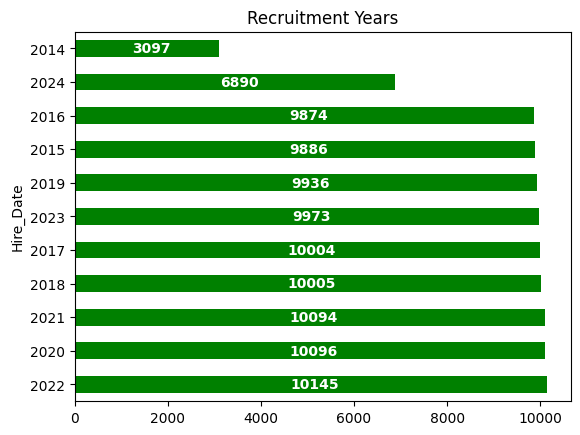

In [66]:
rec_years=df['Hire_Date'].dt.year.value_counts()
axe=rec_years.plot(kind='barh',color='green', title='Recruitment Years')  
for container in axe.containers:
    axe.bar_label(container, padding=3, label_type='center', color='white', fontweight='bold')

Creating new column of year groups

In [67]:
def Tenure_group(Years_At_Company):
    if Years_At_Company <= 2:
        return "0-2 year"
    elif Years_At_Company <= 5:
        return "3-5 years"
    elif Years_At_Company <= 10:
        return "6-10 years"
    else:
        return "+10 years"
    
df['Tenure_Group'] = df['Years_At_Company'].apply(Tenure_group)

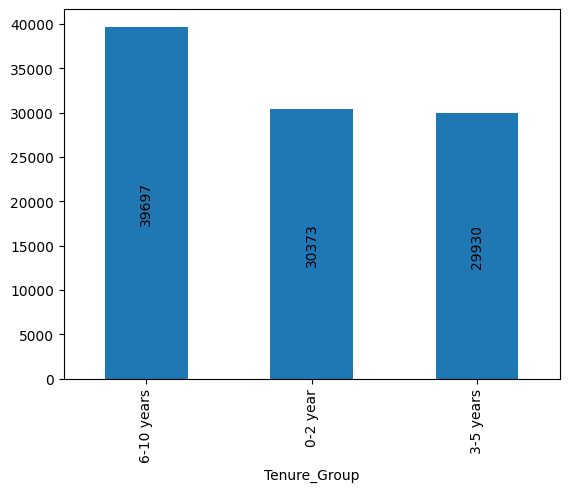

In [68]:
# Check the value counts for the Tenure_Group column
gh=df['Tenure_Group'].value_counts()
axe=gh.plot(kind='bar')
for container in axe.containers:
    axe.bar_label(container, label_type="center", rotation=90)
    

Demographics

<Axes: xlabel='Department'>

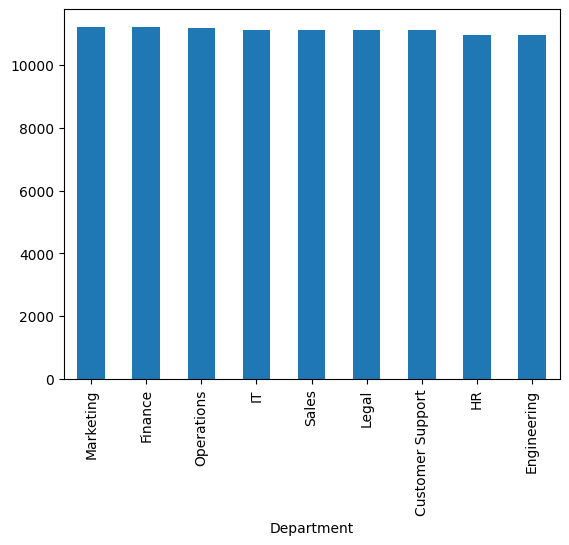

In [69]:
#departments and the number of employees?
dep_emp=df['Department'].value_counts()
dep_emp.plot(kind='bar')

Text(0.5, 1.0, 'Employee Age Distribution')

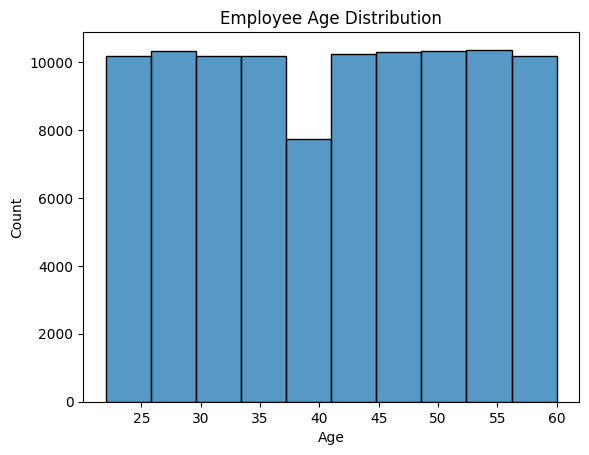

In [70]:
snb.histplot(df["Age"], bins=10)
plt.title("Employee Age Distribution")

In [71]:
df['Employee_Satisfaction_Score'].mean()


np.float64(2.9990883999999998)

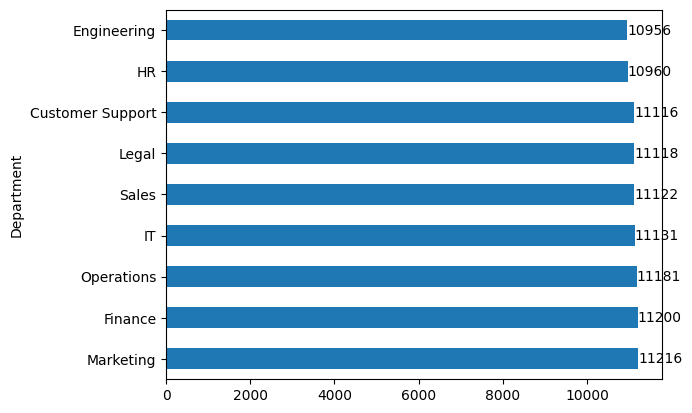

In [72]:
departments_count=df['Department'].value_counts()
axe1=departments_count.plot(kind='barh')
for container in axe1.containers:
    axe1.bar_label(container)

In [73]:
#Departments where many people work more than 40 hours
df_more_than_40 = df[df['Work_Hours_Per_Week'] > 40]
df_more_than_40['Department'].value_counts()

Department
Operations          7212
Finance             7183
Sales               7165
Legal               7156
IT                  7149
Marketing           7149
Engineering         7103
Customer Support    7080
HR                  7027
Name: count, dtype: int64

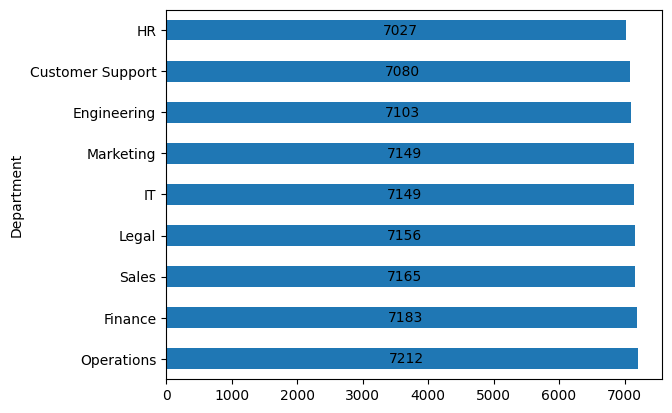

In [74]:
axe2=df_more_than_40["Department"].value_counts()
gh=axe2.plot(kind='barh')
for container in gh.containers:
    gh.bar_label(container, padding=3, label_type='center')

<Axes: >

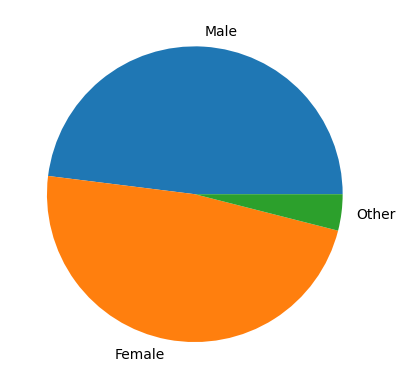

In [75]:
gender_plot=df["Gender"].value_counts()
gender_plot.plot(kind='pie')

<BarContainer object of 3 artists>

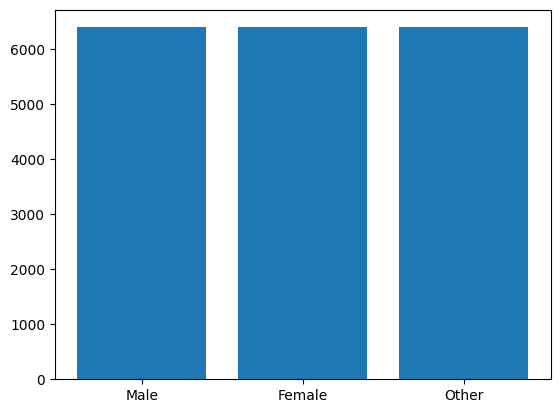

In [76]:
#Average salaries by gender
gender=df['Gender'].unique()
mean_salary=df['Monthly_Salary'].mean()

plt.bar(gender, mean_salary)

Filter the department and count the genders

In [77]:

depart_filter=df[df['Department'] == 'IT']
depart_filter['Gender'].value_counts()

Gender
Male      5366
Female    5315
Other      450
Name: count, dtype: int64

In [97]:
df['Resigned'].value_counts()

Resigned
False    89990
True     10010
Name: count, dtype: int64

In [102]:
# number of resigantions
resigned_true=df[df['Resigned'] == "True"]
resigned_true.value_counts()

Series([], Name: count, dtype: int64)